# Getting started with MemsArray object

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython import display

from megamicros.log import log
from megamicros.db.query import AidbSession
from megamicros.data import MuAudio, generate_moovie
from megamicros.core.base import MemsArray
from megamicros.bmf import Beamformer

log.setLevel( "INFO" )

## Getting signal from DB

In [2]:
# Available labels
LABEL_SOW_FEEDING_CALL = 18
LABEL_PIGLET_SQUEALS = 15
LABEL_SOW_GRUNT_NERVOUS = 16
LABEL_ROOM_NOISE = 29
LABEL_SOW_GRUNT = 8
LABEL_SOW_GRUNT_MODSTRESS  = 1
LABEL_SOW_SCREAMS = 3
LABEL_PIGLET_SQUEALS_2 = 5

# choose label, file and sequence in file:
LABEL_ID = LABEL_SOW_FEEDING_CALL
FILE_ID = 8692          # 5838 (1), 7135 (1), 6860(3), 6560(1)
SEQUENCE_ID = 0         

with AidbSession(
    dbhost='http://dbwelfare.biimea.io/',
    login='ailab',
    email='bruno.gas@biimea.com',
    password='#T;uZnQ5UJ_JC~&' ) as session:
        signal: MuAudio = session.load_labelized( 
            sourcefile_id=FILE_ID, 
            label_id=LABEL_ID, 
            limit=100, 
            channels=list( np.arange( 32 ) + 1 ) 
        )[SEQUENCE_ID]

# get infos
LABEL_TXT = signal.label
CHANNELS_NUMBER = signal.channels_number
SAMPLES_NUMBER = signal.samples_number
SAMPLING_FREQUENCY = signal.sampling_frequency

print( f"Some informations about the signal loaded:" )
print( f" > label={LABEL_TXT}" )
print( f" > channels_number={CHANNELS_NUMBER}" )
print( f" > samples_number={SAMPLES_NUMBER}" )
print( f" > sampling_frequency={SAMPLING_FREQUENCY}" )

# Play sound using channel 0 and 1
left = np.array( signal.channel(0) )
right = np.array( signal.channel(1) )
sound = np.array( [left, right] )

display.Audio(sound, rate=SAMPLING_FREQUENCY )

# Get the whole 32 channels signal as a numpy.ndarray
signal = signal().T

2023-09-11 17:14:36,544 [INFO]:  .Try connecting on endpoint database http://dbwelfare.biimea.io/...
2023-09-11 17:14:36,939 [INFO]:  .Got HTTP 200 status code from server
2023-09-11 17:14:36,940 [INFO]:  .Received CSRF token: h8eoWuuALx58deDWeRjqEEoX26XigPU0. Update session with
2023-09-11 17:14:36,941 [INFO]:  .Received session id: hwn7dn8y8e13kb9wxdjbg4t4ir93gp3c
2023-09-11 17:14:36,942 [INFO]:  .Successfully connected on http://dbwelfare.biimea.io/
2023-09-11 17:14:36,942 [INFO]:  .Downloading labelized audio files from http://dbwelfare.biimea.io/...
2023-09-11 17:14:36,973 [INFO]:  .Found 4 labelized audio files
2023-09-11 17:14:36,974 [INFO]:  .Limit is set to 100 audio files
2023-09-11 17:14:36,975 [INFO]:  .Downloading metadata for object 'sourcefile' [8692]...
2023-09-11 17:14:37,035 [INFO]:  Object sourcefile found with identifier [8692] 
2023-09-11 17:14:41,666 [INFO]:  .Downloading metadata for object 'sourcefile' [8692]...
2023-09-11 17:14:41,734 [INFO]:  Object sourcefile

I'm a NDarray signal with frame size = 80860 and frame number = 1


2023-09-11 17:14:44,578 [INFO]:  .Downloading metadata for object 'sourcefile' [8692]...
2023-09-11 17:14:44,640 [INFO]:  Object sourcefile found with identifier [8692] 


I'm a NDarray signal with frame size = 54536 and frame number = 1


2023-09-11 17:14:47,274 [INFO]:  .Downloading metadata for object 'sourcefile' [8692]...
2023-09-11 17:14:47,339 [INFO]:  Object sourcefile found with identifier [8692] 


I'm a NDarray signal with frame size = 37671 and frame number = 1


2023-09-11 17:14:50,504 [INFO]:  .Trying to disconnect from database http://dbwelfare.biimea.io/...
2023-09-11 17:14:50,535 [INFO]:  .Logout successful.


I'm a NDarray signal with frame size = 67293 and frame number = 1
Some informations about the signal loaded:
 > label=sow-feeding-call
 > channels_number=32
 > samples_number=80860
 > sampling_frequency=10000.0


## Set the beamformer

2023-09-11 17:57:39,900 [INFO]:  .Set beamformer on a 25 MEMs antenna
2023-09-11 17:57:39,901 [INFO]:  .Set beamformer sampling rate on 10000.0 Hz
2023-09-11 17:57:39,902 [INFO]:  .Set beamformer FFT window size to 512 samples
2023-09-11 17:57:39,904 [INFO]:  .Set beamformer space size to [5, 5, 0.01] meters
2023-09-11 17:57:39,907 [INFO]:  .Set beamformer space quantization to [2, 2.1, 100.0] locations/meter
2023-09-11 17:57:39,908 [INFO]:  .Move area from [  0   0 -10] to [  0   0 -12]
2023-09-11 17:57:39,909 [INFO]:  .Checking beamformer parameters...
2023-09-11 17:57:39,910 [INFO]:  .[Ready]
2023-09-11 17:57:39,912 [INFO]:  .Found 100 locations (10 x 10 x 1)
2023-09-11 17:57:39,912 [INFO]:  .Space quantum size is (0.50 x 0.48 x 0.01) meters
2023-09-11 17:57:39,914 [INFO]:  .Set beamformer band width to (0.02, 0.16)
2023-09-11 17:57:39,915 [INFO]:  .Checking beamformer parameters...
2023-09-11 17:57:39,916 [INFO]:  .[Ready]
2023-09-11 17:57:39,918 [INFO]:  .Beamformer2D Initilizatio

2023-09-11 17:57:39,959 [INFO]:  .Build preformed channels matrix H (257 x 100 x 25)


(25, 3)
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
[0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 22, 23, 24, 25, 28, 29, 30, 31]
(80860, 25)


/var/folders/gt/6pstz0nn7zlbgmk_y7m3341c0000gn/T/ipykernel_13221/673276656.py:50: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


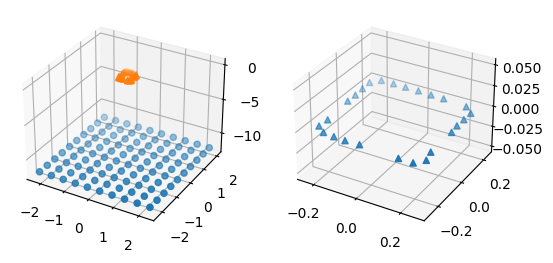

In [18]:
FRAME_LENGTH = 512

# Get the antenna physical description
antenna = np.load ('Antenna-square-JetsonNano-0001.npy', allow_pickle=True )
mems_position = antenna.item().get("positions")
type(mems_position)
print( mems_position.shape )
mems = antenna.item().get('mems')
available_mems = antenna.item().get('available_mems')

# check if some available mems have not been activated
if False in np.isin( available_mems, mems ):
    mask = list( np.invert( np.logical_not( np.isin( available_mems, mems ) ) ) )
    signal = signal[:,mask]



print (available_mems) 
print (mems) 
print( signal.shape )

# Create the beamformer
bmf = Beamformer( 
    mems_position = mems_position,
    sampling_frequency = SAMPLING_FREQUENCY,
    window_size = FRAME_LENGTH,    
    area = [5, 5, 0.01],
    area_quantization = [2, 2.1, 1/0.01]
)

# love the antenna in the right place:
bmf.moveArea( [0, 0, -2] )

# limit the frequency bandwidth form BF computing
bmf.setBandWidth( [100, 800], unit="frequency" )

# Init the beamformer
bmf.init()

# print area locations and antenna 
space_locations = bmf.getLocations()
mems_location = bmf.getMems()

fig = plt.figure()
ax = fig.add_subplot( 121, projection='3d' )
ax.scatter( space_locations[:,0], space_locations[:,1], space_locations[:,2] )
ax.scatter( mems_location[:,0], mems_location[:,1], mems_location[:,2], marker='^' )
ax = fig.add_subplot( 122, projection='3d' )
ax.scatter( mems_location[:,0], mems_location[:,1], mems_location[:,2], marker='^' )
fig.show()


## Compute preformed channels 

In [27]:
FRAMES_NUMBER = SAMPLES_NUMBER // FRAME_LENGTH - 1 

print( f"{FRAMES_NUMBER} frames of {FRAME_LENGTH} samples to perform... " )

nx, ny, nz = bmf.getLocationsNumber()

imgs = []
for i in range( FRAMES_NUMBER ):
    bf = bmf.beamform( signal[i*FRAME_LENGTH:(i+1)*FRAME_LENGTH,:] )
    print( bf.shape )
    imgs.append( np.reshape( bf, (nx, ny) ) )

generate_moovie( 
    imgs, 
    rate=SAMPLING_FREQUENCY/FRAME_LENGTH, 
    sound=sound.astype( np.float32 ).T, 
    sampling_frequency=SAMPLING_FREQUENCY,
    norm=None,
    #extent=( 0, ROOM_SIZE[0], 0, ROOM_SIZE[1] ),
)

156 frames of 512 samples to perform... 
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)


In [29]:
np.shape(imgs)

for i, img in enumerate(imgs):
    plt.imshow( img )
    input()

In [9]:
antenna= {'positions': np.array(
[[-0.2261063,  -0.2217998,   0.        ],
[-0.2231343,  -0.16230868,  0.        ],
[-0.23502814,  0.01106646,  0.        ],
[-0.23505722,  0.07143718,  0.        ],
[-0.23869585,  0.13492614,  0.        ],
[-0.241065,    0.19720244,  0.        ],
[-0.20675762,  0.23860315,  0.        ],
[-0.14724884,  0.23868911,  0.        ],
[-0.08815056,  0.23800337,  0.        ],
[-0.02524838,  0.23605316,  0.        ],
[ 0.03711273,  0.23184893,  0.        ],
[ 0.09778664,  0.22929929,  0.        ],
[ 0.20982932,  0.21545461,  0.        ],
[ 0.25022585,  0.17556075,  0.        ],
[ 0.24945468,  0.11548598,  0.        ],
[ 0.2482488,   0.05719138,  0.        ],
[ 0.25352816,  0.00069583,  0.        ],
[ 0.25355045, -0.17305451,  0.        ],
[ 0.26728441, -0.23428049,  0.        ],
[ 0.23313417, -0.27617064,  0.        ],
[ 0.16906521, -0.27623144,  0.        ],
[-0.01177931, -0.2639107,   0.        ],
[-0.0767392,  -0.26609785,  0.        ],
[-0.13061677, -0.26229372,  0.        ],
[-0.18359293, -0.25536996,  0.        ]] ),
'mems':[0,1,4,5,6,7,8,9,10,11,12,13,15,16,17,18,19,22,23,24,25,28,29,30,31],
'available_mems': [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]
}
np.save( 'Antenna-square-JetsonNano-0001.npy', antenna )

In [8]:
antenna['positions'].shape

(25, 3)

### Do the same with an antenna object

In [ ]:
# Declare a MEMs antenna
antenna = MemsArray( available_mems_number=CHANNELS_NUMBER )

# set active mems
antenna.setActiveMems( [i for i in range( CHANNELS_NUMBER )] )
print( f"active mems number={antenna.mems_number}" )

# iterate over the antenna data stream
#for i, data in enumerate( antenna ):
#    print( f"data={data}")
#    if i > 10:
#        break
